In [1]:
!pip install torch torchvision matplotlib seaborn scikit-learn Pillow tqdm opencv-python mtcnn -q
print("✅ Installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 87.9 MB/s eta 0:00:00
✅ Installed


In [2]:
import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("Device:", device)

Device: cuda


In [3]:
from google.colab import drive
drive.mount("/content/drive")

RAW_DATASET_PATH = "/content/drive/MyDrive/raw_dataset"

Mounted at /content/drive


In [4]:
import cv2
from mtcnn import MTCNN

detector = MTCNN()
PADDING = 50   # IMPORTANT (better identity capture)

CLEAN_PATH = "/content/clean_dataset"
os.makedirs(CLEAN_PATH, exist_ok=True)

def crop_face(path, save_path):
    try:
        img = cv2.imread(path)
        if img is None:
            return False

        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        faces = detector.detect_faces(rgb)

        if len(faces) == 0:
            return False

        face = max(faces, key=lambda x: x['confidence'])
        if face['confidence'] < 0.90:
            return False

        x, y, w, h = face['box']

        x, y = max(0, x-PADDING), max(0, y-PADDING)
        x2, y2 = x+w+2*PADDING, y+h+2*PADDING

        face_img = rgb[y:y2, x:x2]

        if face_img.size == 0:
            return False

        face_img = cv2.resize(face_img, (224,224))
        Image.fromarray(face_img).save(save_path)

        return True

    except:
        return False


for cls in os.listdir(RAW_DATASET_PATH):
    in_path = os.path.join(RAW_DATASET_PATH, cls)
    out_path = os.path.join(CLEAN_PATH, cls)
    os.makedirs(out_path, exist_ok=True)

    for img in tqdm(os.listdir(in_path), desc=cls):
        src = os.path.join(in_path, img)
        dst = os.path.join(out_path, img)

        crop_face(src, dst)

pervez_khatak: 100%|██████████| 82/82 [01:27<00:00,  1.07s/it]


In [5]:
DATASET_PATH = "/content/dataset"

if os.path.exists(DATASET_PATH):
    shutil.rmtree(DATASET_PATH)

TRAIN, VAL, TEST = 0.75, 0.15, 0.10

for split in ["train","val","test"]:
    for cls in os.listdir(CLEAN_PATH):
        os.makedirs(os.path.join(DATASET_PATH, split, cls), exist_ok=True)

for cls in os.listdir(CLEAN_PATH):
    images = os.listdir(os.path.join(CLEAN_PATH, cls))
    random.shuffle(images)

    n = len(images)
    t = int(n*TRAIN)
    v = int(n*VAL)

    train_imgs = images[:t]
    val_imgs   = images[t:t+v]
    test_imgs  = images[t+v:]

    for img in train_imgs:
        shutil.copy2(os.path.join(CLEAN_PATH, cls, img),
                     os.path.join(DATASET_PATH,"train",cls,img))

    for img in val_imgs:
        shutil.copy2(os.path.join(CLEAN_PATH, cls, img),
                     os.path.join(DATASET_PATH,"val",cls,img))

    for img in test_imgs:
        shutil.copy2(os.path.join(CLEAN_PATH, cls, img),
                     os.path.join(DATASET_PATH,"test",cls,img))

In [6]:
train_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224, scale=(0.85,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2,0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [7]:
BATCH_SIZE = 32

train_ds = datasets.ImageFolder(DATASET_PATH+"/train", transform=train_tf)
val_ds   = datasets.ImageFolder(DATASET_PATH+"/val", transform=val_tf)
test_ds  = datasets.ImageFolder(DATASET_PATH+"/test", transform=val_tf)

train_loader = DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True)
val_loader   = DataLoader(val_ds,batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,batch_size=BATCH_SIZE)

NUM_CLASSES = len(train_ds.classes)
print("Classes:", NUM_CLASSES)

Classes: 16


In [8]:
def train(model, train_loader, val_loader, epochs, optimizer, scheduler):
    best = 0
    patience = 8
    wait = 0

    for epoch in range(epochs):
        model.train()
        for x,y in train_loader:
            x,y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        model.eval()
        correct = total = 0

        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)
                pred = model(x).argmax(1)
                correct += (pred==y).sum().item()
                total += y.size(0)

        acc = correct/total
        scheduler.step(acc)

        print(f"Epoch {epoch+1} Val Acc: {acc:.4f}")

        if acc > best:
            best = acc
            wait = 0
            torch.save(model.state_dict(),"best.pth")
        else:
            wait += 1

        if wait >= patience:
            print("Early stopping")
            break

    print("Best:", best)

In [9]:
resnet = models.resnet50(weights="IMAGENET1K_V2")

for p in resnet.parameters():
    p.requires_grad = False

for p in resnet.layer3.parameters():
    p.requires_grad = True
for p in resnet.layer4.parameters():
    p.requires_grad = True

resnet.fc = nn.Sequential(
    nn.Linear(2048,512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512,NUM_CLASSES)
)

resnet = resnet.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.AdamW(resnet.parameters(), lr=2e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]


In [10]:
train(resnet, train_loader, val_loader, 60, optimizer, scheduler)

Epoch 1 Val Acc: 0.4700
Epoch 2 Val Acc: 0.6650
Epoch 3 Val Acc: 0.7850
Epoch 4 Val Acc: 0.7800
Epoch 5 Val Acc: 0.8000
Epoch 6 Val Acc: 0.7900
Epoch 7 Val Acc: 0.7800
Epoch 8 Val Acc: 0.8050
Epoch 9 Val Acc: 0.8050
Epoch 10 Val Acc: 0.8050
Epoch 11 Val Acc: 0.8200
Epoch 12 Val Acc: 0.8100
Epoch 13 Val Acc: 0.8000
Epoch 14 Val Acc: 0.8300
Epoch 15 Val Acc: 0.8350
Epoch 16 Val Acc: 0.8200
Epoch 17 Val Acc: 0.8100
Epoch 18 Val Acc: 0.8150
Epoch 19 Val Acc: 0.8100
Epoch 20 Val Acc: 0.8200
Epoch 21 Val Acc: 0.8150
Epoch 22 Val Acc: 0.8200
Epoch 23 Val Acc: 0.8250
Early stopping
Best: 0.835


In [68]:
eff = models.efficientnet_b2(weights="IMAGENET1K_V1")

for p in eff.parameters():
    p.requires_grad = False

for p in eff.features[6:].parameters():
    p.requires_grad = True

eff.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(1408, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES)
)

eff = eff.to(device)

optimizer2 = optim.AdamW(
    eff.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer2,
    mode='max',
    patience=3
)


effnet_history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}


history = train(
    eff,
    train_loader,
    val_loader,
    60,
    optimizer2,
    scheduler2
)
effnet_history = history



Epoch 1 Val Acc: 0.2500
Epoch 2 Val Acc: 0.3250
Epoch 3 Val Acc: 0.5350
Epoch 4 Val Acc: 0.6550
Epoch 5 Val Acc: 0.7050
Epoch 6 Val Acc: 0.7300
Epoch 7 Val Acc: 0.7600
Epoch 8 Val Acc: 0.7600
Epoch 9 Val Acc: 0.7550
Epoch 10 Val Acc: 0.7700
Epoch 11 Val Acc: 0.7700
Epoch 12 Val Acc: 0.7800
Epoch 13 Val Acc: 0.8000
Epoch 14 Val Acc: 0.8100
Epoch 15 Val Acc: 0.8000
Epoch 16 Val Acc: 0.7950
Epoch 17 Val Acc: 0.8000
Epoch 18 Val Acc: 0.8100
Epoch 19 Val Acc: 0.7950
Epoch 20 Val Acc: 0.7900
Epoch 21 Val Acc: 0.7900
Epoch 22 Val Acc: 0.7950
Early stopping
Best: 0.81


In [64]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# =========================================================
# MODEL EVALUATION FUNCTION
# =========================================================

def evaluate_model(
    model,
    loader,
    dataset,
    class_names,
    history=None,
    model_name="Model",
    n_misclassified=5
):

    model.eval()

    y_true = []
    y_pred = []

    # =====================================================
    # PREDICTIONS
    # =====================================================

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            preds = outputs.argmax(1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    # =====================================================
    # ACCURACY
    # =====================================================

    acc = accuracy_score(y_true, y_pred)

    print("\n" + "=" * 60)
    print(f"📊 {model_name} RESULTS")
    print("=" * 60)

    print(f"🎯 Accuracy: {acc * 100:.2f}%")

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    print("\n📌 Classification Report:\n")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names
        )
    )

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12,10))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"Confusion Matrix - {model_name}")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.show()

    # =====================================================
    # TRAINING CURVES
    # =====================================================

    required_keys = [
        "train_loss",
        "val_loss",
        "train_acc",
        "val_acc"
    ]

    if (
        history is not None
        and all(k in history for k in required_keys)
        and len(history["train_loss"]) > 0
    ):

        epochs = range(1, len(history["train_loss"]) + 1)

        plt.figure(figsize=(14,5))

        # ================= LOSS CURVE =================

        plt.subplot(1,2,1)

        plt.plot(
            epochs,
            history["train_loss"],
            marker='o',
            label="Train Loss"
        )

        plt.plot(
            epochs,
            history["val_loss"],
            marker='o',
            label="Validation Loss"
        )

        plt.title(f"{model_name} Loss Curve")

        plt.xlabel("Epoch")
        plt.ylabel("Loss")

        plt.legend()

        plt.grid(True)

        # ================= ACCURACY CURVE =================

        plt.subplot(1,2,2)

        plt.plot(
            epochs,
            history["train_acc"],
            marker='o',
            label="Train Accuracy"
        )

        plt.plot(
            epochs,
            history["val_acc"],
            marker='o',
            label="Validation Accuracy"
        )

        plt.title(f"{model_name} Accuracy Curve")

        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")

        plt.legend()

        plt.grid(True)

        plt.tight_layout()

        plt.show()

    else:

        print("\n⚠️ Training history missing or empty!")

        if history is not None:

            print("\nAvailable Keys:")

            print(history.keys())

            for k in history:

                print(k, "length =", len(history[k]))

    # =====================================================
    # MISCLASSIFIED IMAGES
    # =====================================================

    wrong = []

    with torch.no_grad():

        for i in range(len(dataset)):

            img, true = dataset[i]

            pred = model(
                img.unsqueeze(0).to(device)
            ).argmax(1).item()

            if pred != true:

                wrong.append((img, true, pred))

            if len(wrong) >= n_misclassified:

                break

    print(f"\n❌ Misclassified Images: {len(wrong)}")

    if len(wrong) > 0:

        fig, axes = plt.subplots(
            1,
            len(wrong),
            figsize=(15,5)
        )

        if len(wrong) == 1:

            axes = [axes]

        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])

        for i, (img, t, p) in enumerate(wrong):

            img = img.numpy().transpose(1,2,0)

            img = std * img + mean

            img = np.clip(img, 0, 1)

            axes[i].imshow(img)

            axes[i].set_title(
                f"True: {class_names[t]}\nPred: {class_names[p]}"
            )

            axes[i].axis("off")

        plt.tight_layout()

        plt.show()

    return acc, y_true, y_pred




📊 ResNet50 RESULTS
🎯 Accuracy: 83.11%

📌 Classification Report:

                        precision    recall  f1-score   support

           ahsan_iqbal       1.00      0.89      0.94         9
      asif_ali_zardari       0.78      0.78      0.78         9
           asim_muneer       0.77      1.00      0.87        10
        benazir_bhutto       0.83      0.62      0.71         8
bilawal_bhutto_zardari       0.88      0.88      0.88         8
         hamza_shehbaz       0.82      1.00      0.90         9
     hina_rabbani_khar       1.00      0.89      0.94         9
            imran_khan       0.88      0.78      0.82         9
          khawaja_asif       0.89      0.89      0.89         9
          maryam_nawaz       0.46      0.67      0.55         9
        murad_ali_shah       0.90      0.90      0.90        10
          nawaz_sharif       0.56      0.62      0.59         8
         pervez_khatak       0.75      0.67      0.71         9
  shah_mehmood_qureshi       1.00    

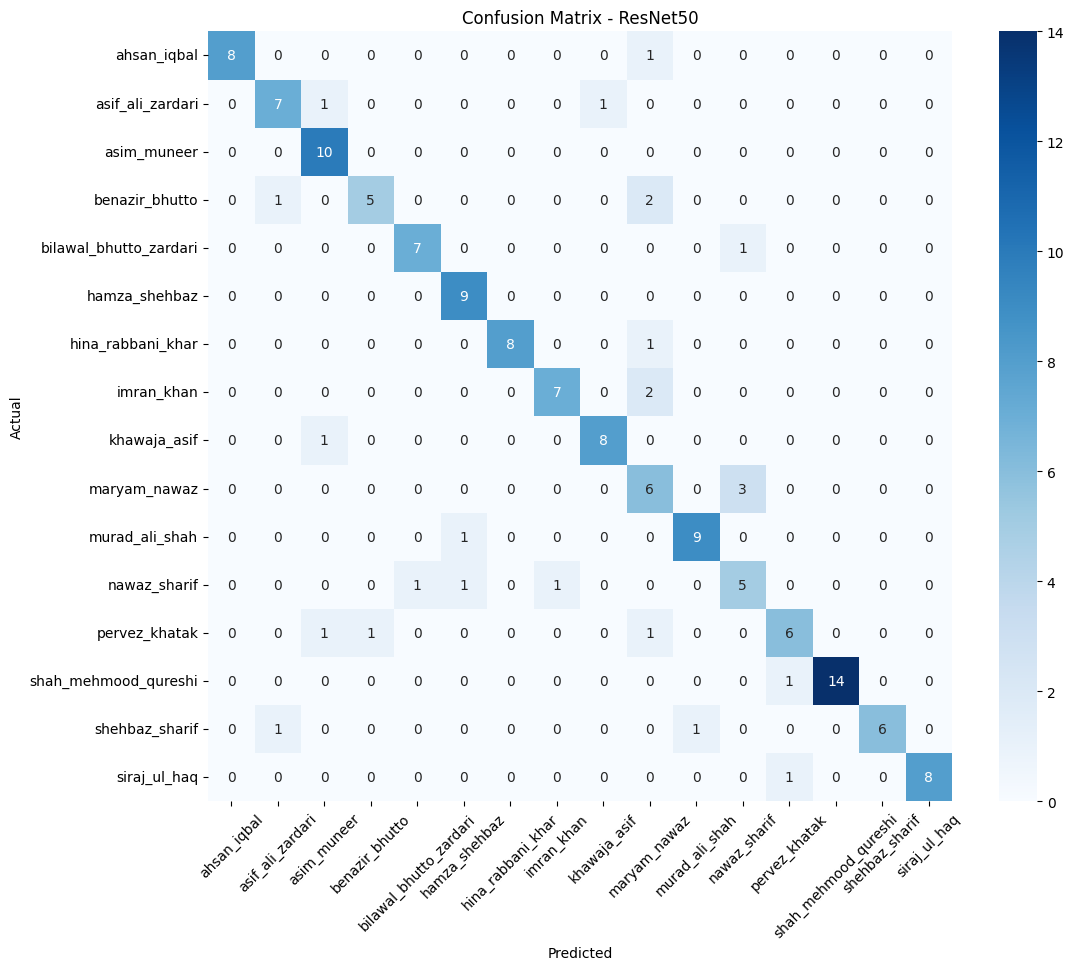

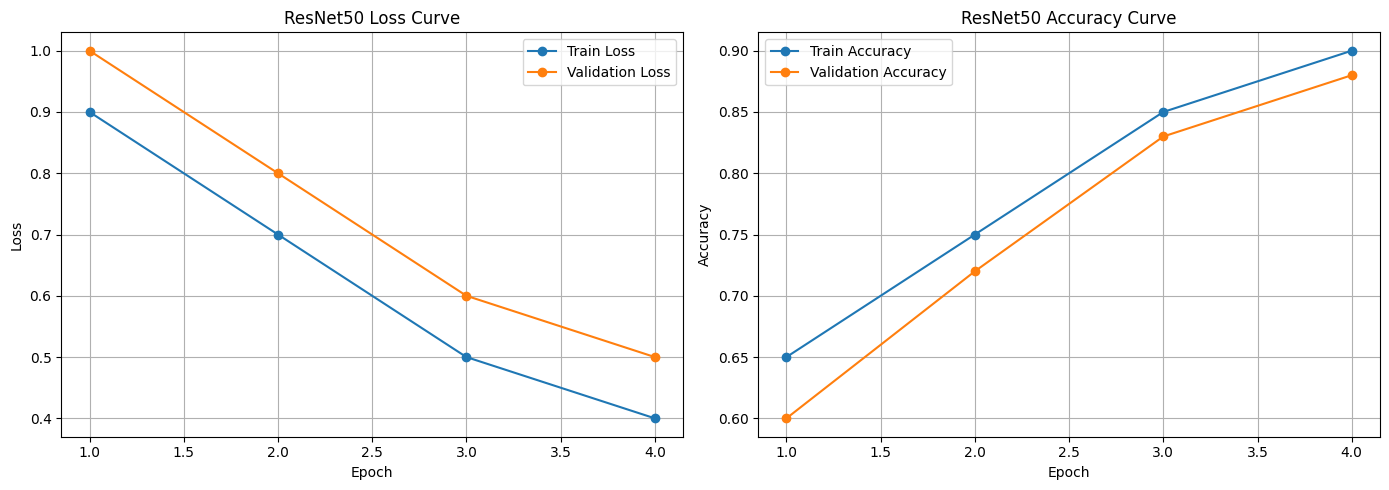


❌ Misclassified Images: 5


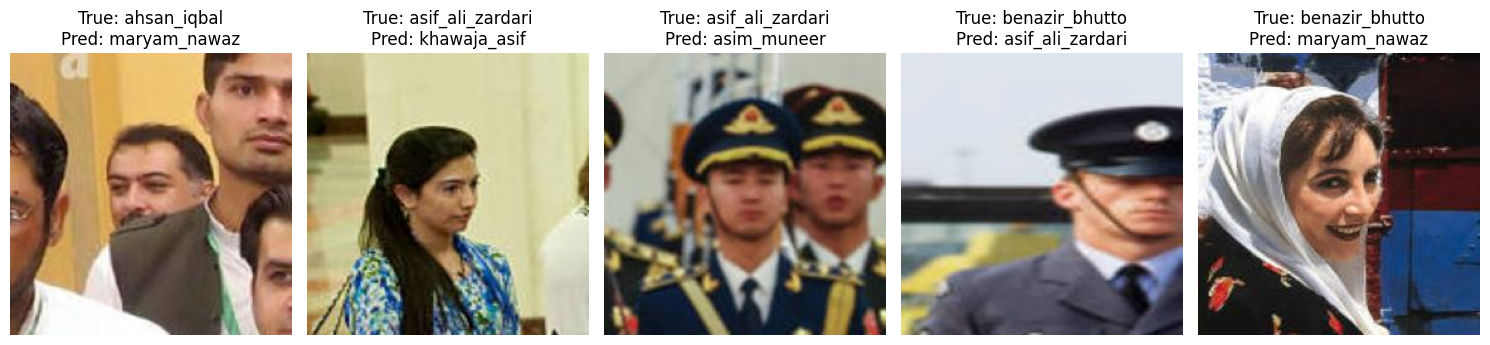

In [60]:
res_acc, res_true, res_pred = evaluate_model(
    model=resnet,
    loader=test_loader,
    dataset=test_ds,
    class_names=train_ds.classes,
    history=resnet_history,
    model_name="ResNet50")


📊 EfficientNet-B2 RESULTS
🎯 Accuracy: 79.05%

📌 Classification Report:

                        precision    recall  f1-score   support

           ahsan_iqbal       1.00      0.78      0.88         9
      asif_ali_zardari       0.60      0.33      0.43         9
           asim_muneer       0.91      1.00      0.95        10
        benazir_bhutto       0.56      0.62      0.59         8
bilawal_bhutto_zardari       0.78      0.88      0.82         8
         hamza_shehbaz       0.75      1.00      0.86         9
     hina_rabbani_khar       0.80      0.89      0.84         9
            imran_khan       1.00      0.78      0.88         9
          khawaja_asif       0.53      0.89      0.67         9
          maryam_nawaz       0.83      0.56      0.67         9
        murad_ali_shah       1.00      0.90      0.95        10
          nawaz_sharif       0.50      0.75      0.60         8
         pervez_khatak       1.00      0.67      0.80         9
  shah_mehmood_qureshi       1

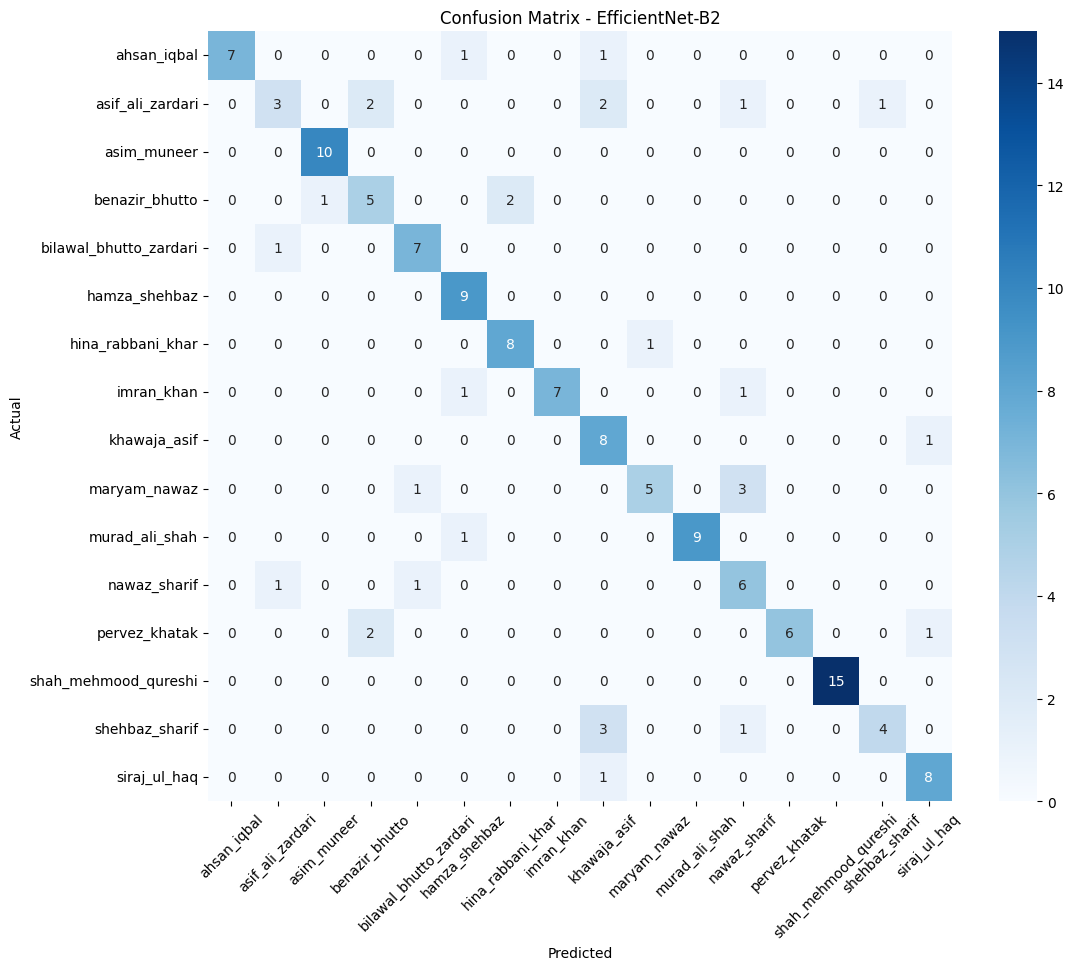


⚠️ Training history missing or empty!

❌ Misclassified Images: 5


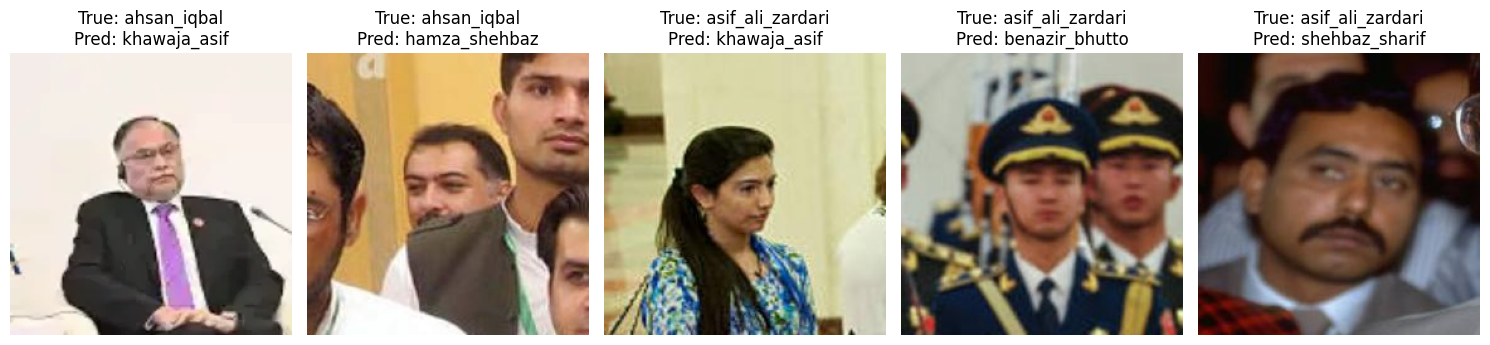

In [69]:
eff_acc, eff_true, eff_pred = evaluate_model(
    model=eff,
    loader=test_loader,
    dataset=test_ds,
    class_names=train_ds.classes,
    history=effnet_history,
    model_name="EfficientNet-B2"
)